# BattleDIM Water Leakage Dataset — Exploratory Starter Notebook

This notebook explores the combined and cleaned dataset at:

`/mnt/data/data_full_2018_2019_fixed.csv`

the goal is to make sure the cleaned\preprocced dataset align with raw data
- dataset structure and column groups
- quality checks and timestamp integrity
- leak labels, classes
- leakage-specific summaries and plots
- sensor statistics and feature relationships

In [1]:
%matplotlib inline
import json
import warnings
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f"{x:,.3f}")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

DATA_PATH = Path('/mnt/data/data_full_2018_2019_fixed.csv')
ARTIFACT_DIR = Path('/mnt/data')

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['Timestamp']).sort_values('Timestamp').reset_index(drop=True)
raw_rows, raw_cols = df.shape

press_cols = [c for c in df.columns if c.startswith('press_')]
pipe_cols = [c for c in df.columns if c.startswith('pipe_')]
flow_cols = [c for c in df.columns if c.startswith('flow_')]
leak_cols = [c for c in df.columns if c.startswith('leak_')]
node_cols = [c for c in df.columns if c.startswith('n') and c[1:].isdigit()]
other_sensor_cols = [c for c in df.columns if c not in ['Timestamp'] + press_cols + pipe_cols + flow_cols + leak_cols + node_cols]
sensor_cols = press_cols + flow_cols + other_sensor_cols + node_cols
base_columns = ['Timestamp'] + press_cols + pipe_cols + leak_cols + flow_cols + other_sensor_cols + node_cols

pipe_state_bits = df[pipe_cols].astype(int).astype(str).agg(''.join, axis=1)
active_pipe_count = df[pipe_cols].sum(axis=1)

for col, series in {
    'year': df['Timestamp'].dt.year,
    'year_month': df['Timestamp'].dt.to_period('M').astype(str),
    'date': df['Timestamp'].dt.date,
    'hour': df['Timestamp'].dt.hour,
    'dayofweek': df['Timestamp'].dt.dayofweek,
    'month': df['Timestamp'].dt.month,
    'is_weekend': df['Timestamp'].dt.dayofweek.isin([5, 6]).astype(int),
}.items():
    df[col] = series


def column_group(col):
    if col == 'Timestamp':
        return 'timestamp'
    if col in press_cols:
        return 'pressure_sensor'
    if col in pipe_cols:
        return 'pipe_label'
    if col in leak_cols:
        return 'leak_target'
    if col in flow_cols:
        return 'flow_sensor'
    if col in node_cols:
        return 'node_sensor'
    if col in other_sensor_cols:
        return 'other_sensor'
    return 'derived'


def bits_to_pipe_names(bits):
    active = [pipe_cols[i].replace('_bin', '') for i, bit in enumerate(bits) if bit == '1']
    return ', '.join(active) if active else 'no_leak'

print(f"Loaded dataset: {raw_rows:,} rows x {raw_cols:,} original columns")

Loaded dataset: 210,240 rows x 137 original columns


## 1) Overview and structure

In [3]:
memory_mb = df[base_columns].memory_usage(deep=True).sum() / 1024**2

overview = pd.DataFrame({
    'metric': [
        'rows', 'columns', 'date_start', 'date_end', 'memory_mb',
        'pressure_columns', 'flow_columns', 'node_columns', 'pipe_label_columns', 'leak_target_columns', 'other_sensor_columns'
    ],
    'value': [
        raw_rows,
        raw_cols,
        df['Timestamp'].min(),
        df['Timestamp'].max(),
        round(memory_mb, 2),
        len(press_cols),
        len(flow_cols),
        len(node_cols),
        len(pipe_cols),
        len(leak_cols),
        len(other_sensor_cols),
    ]
})

group_counts = pd.DataFrame({
    'group': ['pressure_sensor', 'flow_sensor', 'node_sensor', 'pipe_label', 'leak_target', 'other_sensor'],
    'n_columns': [len(press_cols), len(flow_cols), len(node_cols), len(pipe_cols), len(leak_cols), len(other_sensor_cols)]
}).sort_values('n_columns', ascending=False)

column_profile = pd.DataFrame({
    'column': base_columns,
    'group': [column_group(c) for c in base_columns],
    'dtype': df[base_columns].dtypes.astype(str).values,
    'missing': df[base_columns].isna().sum().values,
    'nunique': df[base_columns].nunique().values,
})

print('Dataset overview')
display(overview)
print('Column group counts')
display(group_counts)
print('Sample rows')
display(df[base_columns].head(3))

Dataset overview


,metric,value
0,rows,210240
1,columns,137
2,date_start,2018-01-01 00:00:00
3,date_end,2019-12-31 23:55:00
4,memory_mb,219.750
5,pressure_columns,33
6,flow_columns,3
7,node_columns,82
8,pipe_label_columns,14
9,leak_target_columns,3


Column group counts


,group,n_columns
2,node_sensor,82
0,pressure_sensor,33
3,pipe_label,14
1,flow_sensor,3
4,leak_target,3
5,other_sensor,1


Sample rows


,Timestamp,press_1,press_2,press_3,press_4,press_5,press_6,press_7,press_8,press_9,press_10,press_11,press_12,press_13,press_14,press_15,press_16,press_17,press_18,press_19,press_20,press_21,press_22,press_23,press_24,press_25,press_26,press_27,press_28,press_29,press_30,press_31,press_32,press_33,pipe_1_bin,pipe_2_bin,pipe_3_bin,pipe_4_bin,pipe_5_bin,pipe_6_bin,pipe_7_bin,pipe_8_bin,pipe_9_bin,pipe_10_bin,pipe_11_bin,pipe_12_bin,pipe_13_bin,pipe_14_bin,leak_mag_total,leak_count,leak_binary,flow_1,flow_2,flow_3,T1,n1,n2,n3,n4,n6,n7,n8,n9,n10,n11,n13,n16,n17,n18,n19,n20,n21,n22,n23,n24,n25,n26,n27,n28,n29,n30,n31,n32,n33,n34,n35,n36,n39,n40,n41,n42,n43,n44,n45,n343,n344,n345,n346,n347,n349,n350,n351,n352,n353,n354,n355,n356,n357,n358,n360,n361,n362,n364,n365,n366,n367,n368,n369,n370,n371,n372,n373,n374,n375,n376,n377,n378,n379,n381,n382,n383,n384,n385,n386,n387,n388,n389
0,2018-01-01 00:00:00,28.920,33.870,37.130,37.130,50.520,53.990,52.560,55.320,39.090,52.530,52.810,42.450,56.430,46.750,31.070,45.620,36.790,43.520,47.540,51.700,53.540,54.850,47.580,54.800,56.160,45.530,47.620,47.330,46.140,47.120,43.810,49.170,48.500,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0,0,77.770,83.930,44.040,3.500,40.830,112.230,96.710,131.290,166.180,81.920,249.950,489.630,58.830,495.980,266.970,99.390,251.800,70.030,85.340,48.120,53.850,135.470,194.870,39.390,989.730,32.630,66.150,540.760,65.420,134.280,99.560,67.560,103.780,0.000,41.650,210.530,10.800,323.740,74.670,111.300,19.730,24.960,98.540,94.250,120.710,41.930,200.020,0.640,27.240,83.990,329.380,93.910,359.980,126.690,0.000,118.260,90.400,241.930,250.670,137.420,6.220,18.580,114.430,56.900,77.960,75.700,96.520,206.120,85.180,47.010,10.370,16.380,60.490,58.270,318.460,4.350,33.410,150.820,67.610,65.820,65.250,57.390,214.200,81.490,256.500,92.140
1,2018-01-01 00:05:00,28.940,33.890,37.160,37.230,50.600,54.090,52.670,55.420,39.100,52.670,52.880,42.480,56.520,46.850,31.180,45.710,36.900,43.620,47.620,51.750,53.630,54.960,47.670,54.900,56.260,45.610,47.710,47.390,46.190,47.170,43.830,49.220,48.540,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0,0,72.510,76.340,44.060,3.510,40.200,166.050,239.530,136.210,154.480,372.140,190.560,171.600,38.020,142.360,204.210,63.410,234.080,61.370,81.810,113.650,15.460,114.080,66.720,20.630,"1,045.720",27.480,31.470,300.570,32.920,332.560,69.520,35.380,2.950,40.900,30.050,147.010,10.350,317.530,106.940,159.390,54.970,36.930,232.740,149.760,172.870,32.670,173.100,0.740,39.010,73.900,167.830,8.060,181.160,111.020,158.980,42.960,59.690,115.080,245.860,48.160,2.590,84.390,63.070,60.230,43.290,112.010,123.730,382.750,54.350,35.960,24.490,80.900,33.340,86.580,191.640,4.610,78.900,97.460,95.290,50.180,81.290,49.670,109.140,104.460,394.480,203.610
2,2018-01-01 00:10:00,28.960,33.910,37.180,37.210,50.570,54.050,52.640,55.390,39.090,52.640,52.890,42.500,56.490,46.840,31.160,45.680,36.880,43.600,47.590,51.730,53.600,54.930,47.650,54.870,56.240,45.610,47.710,47.410,46.200,47.190,43.840,49.240,48.560,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0,0,71.540,78.680,44.060,3.530,38.060,121.910,69.120,131.000,160.100,320.790,242.070,39.350,52.790,225.650,95.820,64.720,242.590,19.320,72.390,144.420,24.500,83.140,91.220,2.530,"1,131.460",5.360,42.730,237.690,21.480,95.970,81.710,4.350,89.300,25.190,10.890,172.800,9.160,159.180,29.210,43.530,84.380,27.110,295.740,112.560,47.210,27.260,33.790,0.820,10.660,149.120,439.500,31.600,118.200,34.960,97.920,104.200,90.400,156.280,123.250,11.040,5.140,72.740,130.990,118.600,104.620,82.230,111.720,280.280,55.470,16.870,31.120,135.790,69.250,103.600,286.080,9.070,100.260,135.330,178.100,63.740,252.940,9.690,285.820,94.320,337.330,93.110


In [4]:
buf = StringIO()
df[base_columns].info(buf=buf)
print(buf.getvalue())
print('Column profile preview')
display(column_profile.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210240 entries, 0 to 210239
Columns: 137 entries, Timestamp to n389
dtypes: datetime64[ns](1), float64(120), int64(16)
memory usage: 219.7 MB

Column profile preview


,column,group,dtype,missing,nunique
0,Timestamp,timestamp,datetime64[ns],0,210240
1,press_1,pressure_sensor,float64,0,355
2,press_2,pressure_sensor,float64,0,334
3,press_3,pressure_sensor,float64,0,283
4,press_4,pressure_sensor,float64,0,461
5,press_5,pressure_sensor,float64,0,214
6,press_6,pressure_sensor,float64,0,249
7,press_7,pressure_sensor,float64,0,388
8,press_8,pressure_sensor,float64,0,385
9,press_9,pressure_sensor,float64,0,22


## 2) Data quality audit

In [5]:
time_diff = df['Timestamp'].diff().dropna()
expected_freq = pd.Timedelta(minutes=5)
expected_rows = len(pd.date_range(df['Timestamp'].min(), df['Timestamp'].max(), freq='5min'))

quality_audit = pd.DataFrame({
    'check': [
        'missing_cells_total',
        'duplicate_rows',
        'duplicate_timestamps',
        'non_5min_gaps',
        'expected_rows_at_5min_frequency',
        'actual_rows',
        'row_count_matches_expected'
    ],
    'value': [
        int(df[base_columns].isna().sum().sum()),
        int(df[base_columns].duplicated().sum()),
        int(df['Timestamp'].duplicated().sum()),
        int((time_diff != expected_freq).sum()),
        int(expected_rows),
        int(raw_rows),
        bool(expected_rows == raw_rows),
    ]
})

display(quality_audit)

,check,value
0,missing_cells_total,0
1,duplicate_rows,0
2,duplicate_timestamps,0
3,non_5min_gaps,0
4,expected_rows_at_5min_frequency,210240
5,actual_rows,210240
6,row_count_matches_expected,True


## 3) Leak labels, classes, and target sanity checks

These checks are important before any modeling. They reveal whether some columns are derived from others and therefore must be excluded from the feature set for certain tasks.

In [6]:
label_sanity = pd.DataFrame({
    'check': [
        'leak_binary == (leak_count > 0)',
        'leak_binary == (leak_mag_total > 0)',
        'leak_count == sum(pipe_*_bin)',
        'unique leak_binary classes',
        'unique leak_count classes',
        'unique pipe-state combinations',
        'first positive leak timestamp',
        'rows with no leak',
        'hours with no leak'
    ],
    'value': [
        bool(((df['leak_count'] > 0).astype(int) == df['leak_binary']).all()),
        bool(((df['leak_mag_total'] > 0).astype(int) == df['leak_binary']).all()),
        bool((active_pipe_count == df['leak_count']).all()),
        int(df['leak_binary'].nunique()),
        int(df['leak_count'].nunique()),
        int(pipe_state_bits.nunique()),
        df.loc[df['leak_binary'].eq(1), 'Timestamp'].min(),
        int(df['leak_binary'].eq(0).sum()),
        round(df['leak_binary'].eq(0).sum() * 5 / 60, 2),
    ]
})

display(label_sanity)

,check,value
0,leak_binary == (leak_count > 0),True
1,leak_binary == (leak_mag_total > 0),True
2,leak_count == sum(pipe_*_bin),True
3,unique leak_binary classes,2
4,unique leak_count classes,10
5,unique pipe-state combinations,36
6,first positive leak timestamp,2018-01-09 00:30:00
7,rows with no leak,2310
8,hours with no leak,192.500


In [7]:
binary_counts = (
    df['leak_binary']
    .value_counts()
    .rename_axis('class')
    .reset_index(name='rows')
    .sort_values('class')
)
binary_counts['pct'] = 100 * binary_counts['rows'] / len(df)

count_counts = (
    df['leak_count']
    .value_counts()
    .rename_axis('class')
    .reset_index(name='rows')
    .sort_values('class')
)
count_counts['pct'] = 100 * count_counts['rows'] / len(df)

pipe_prevalence = (
    df[pipe_cols]
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .rename('pct_active_rows')
    .reset_index()
    .rename(columns={'index': 'pipe'})
)

combo_counts = (
    pipe_state_bits
    .value_counts()
    .rename_axis('pipe_state_bits')
    .reset_index(name='rows')
)
combo_counts['pct'] = 100 * combo_counts['rows'] / len(df)
combo_counts['n_active_pipes'] = combo_counts['pipe_state_bits'].str.count('1')
combo_counts['active_pipes'] = combo_counts['pipe_state_bits'].apply(bits_to_pipe_names)

print('Leak binary class balance')
display(binary_counts)
print('Leak count class balance')
display(count_counts)
print(f"Total distinct pipe-state classes: {combo_counts.shape[0]}")
print('Most common pipe-state classes')
display(combo_counts.head(15))

Leak binary class balance


,class,rows,pct
1,0,2310,1.099
0,1,207930,98.901


Leak count class balance


,class,rows,pct
9,0,2310,1.099
8,1,4313,2.051
4,2,24269,11.543
1,3,32338,15.381
0,4,49865,23.718
3,5,29003,13.795
6,6,12718,6.049
2,7,29982,14.261
7,8,6019,2.863
5,9,19423,9.238


Total distinct pipe-state classes: 36
Most common pipe-state classes


,pipe_state_bits,rows,pct,n_active_pipes,active_pipes
0,00001010001010,25935,12.336,4,"pipe_5, pipe_7, pipe_11, pipe_13"
1,10111111110000,19423,9.238,9,"pipe_1, pipe_3, pipe_4, pipe_5, pipe_6, pipe_7..."
2,00111110100010,14553,6.922,7,"pipe_3, pipe_4, pipe_5, pipe_6, pipe_7, pipe_9..."
3,00001010000000,13603,6.470,2,"pipe_5, pipe_7"
4,01111110100000,9955,4.735,7,"pipe_2, pipe_3, pipe_4, pipe_5, pipe_6, pipe_7..."
5,00010100100001,8496,4.041,4,"pipe_4, pipe_6, pipe_9, pipe_14"
6,00001011000000,7929,3.771,3,"pipe_5, pipe_7, pipe_8"
7,00010000100000,6938,3.300,2,"pipe_4, pipe_9"
8,10001010001000,6738,3.205,4,"pipe_1, pipe_5, pipe_7, pipe_11"
9,00010100100000,6283,2.988,3,"pipe_4, pipe_6, pipe_9"


In [1]:
binary_counts['class'].astype(str), binary_counts['rows']

NameError: name 'binary_counts' is not defined

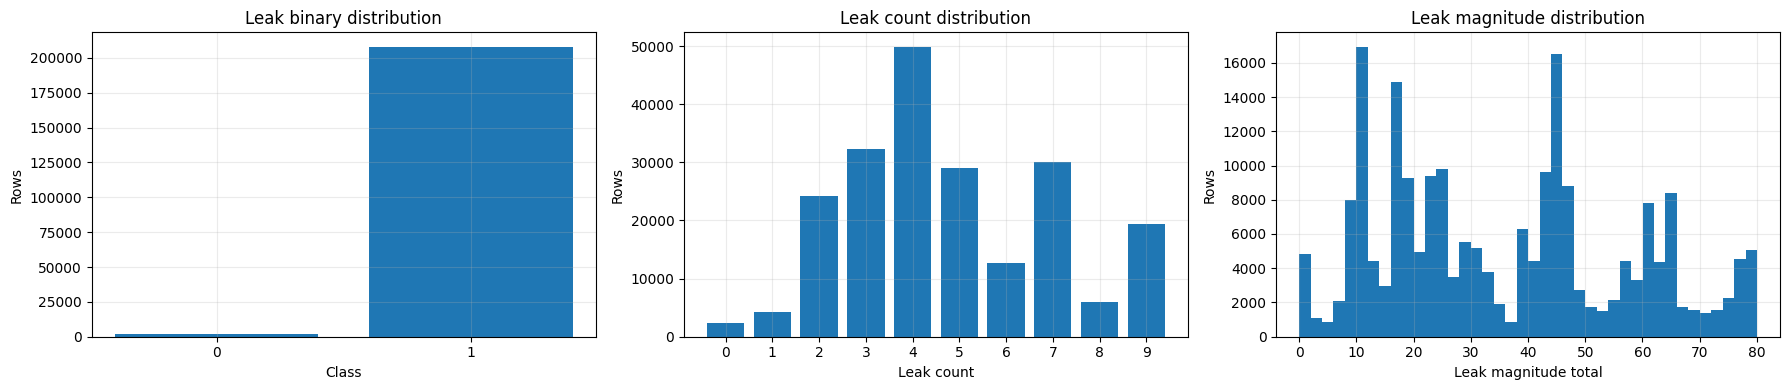

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(binary_counts['class'].astype(str), binary_counts['rows'])
axes[0].set_title('Leak binary distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Rows')

axes[1].bar(count_counts['class'].astype(str), count_counts['rows'])
axes[1].set_title('Leak count distribution')
axes[1].set_xlabel('Leak count')
axes[1].set_ylabel('Rows')

axes[2].hist(df['leak_mag_total'], bins=40)
axes[2].set_title('Leak magnitude distribution')
axes[2].set_xlabel('Leak magnitude total')
axes[2].set_ylabel('Rows')

plt.tight_layout()
plt.show()

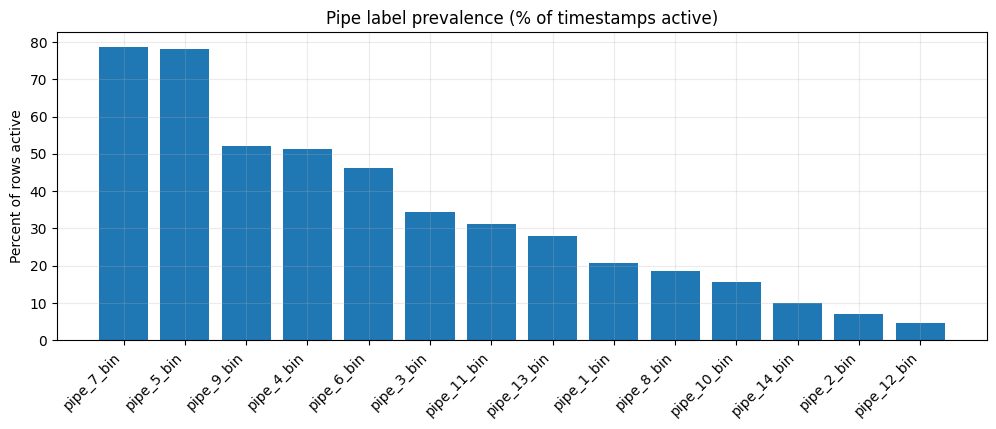

In [9]:
plt.figure(figsize=(12, 4))
plt.bar(pipe_prevalence['index'] if 'index' in pipe_prevalence.columns else pipe_prevalence['pipe'], pipe_prevalence['pct_active_rows'])
plt.title('Pipe label prevalence (% of timestamps active)')
plt.ylabel('Percent of rows active')
plt.xticks(rotation=45, ha='right')
plt.show()

,count,mean,median,min,max
leak_count,,,,,
0,2310,0.000,0.000,0.000,0.000
1,4313,1.963,1.510,0.010,5.730
2,24269,10.341,10.690,5.740,11.980
3,32338,25.729,19.660,7.290,47.340
4,49865,28.396,23.550,12.720,80.040
5,29003,39.002,42.900,25.320,49.880
6,12718,45.243,42.930,27.610,61.940
7,29982,55.235,57.070,41.820,66.250
8,6019,47.218,46.700,45.140,65.630


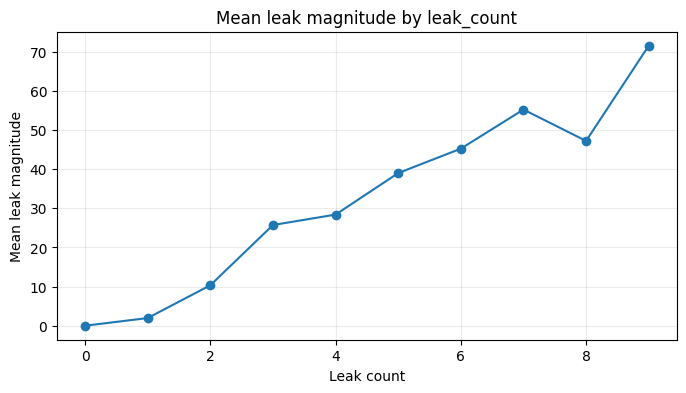

In [10]:
leak_mag_by_count = (
    df.groupby('leak_count')['leak_mag_total']
    .agg(['count', 'mean', 'median', 'min', 'max'])
)

display(leak_mag_by_count)

plt.figure(figsize=(8, 4))
plt.plot(leak_mag_by_count.index, leak_mag_by_count['mean'], marker='o')
plt.title('Mean leak magnitude by leak_count')
plt.xlabel('Leak count')
plt.ylabel('Mean leak magnitude')
plt.show()

In [11]:
task_catalog = pd.DataFrame({
    'task': [
        'Binary leak detection',
        'Leak-count classification',
        'Leak-magnitude regression',
        'Pipe localization (multilabel)',
        'Pipe-state multiclass classification'
    ],
    'target': [
        'leak_binary',
        'leak_count',
        'leak_mag_total',
        '14 pipe_*_bin columns',
        'pipe_state_bits'
    ],
    'classes_or_type': [
        int(df['leak_binary'].nunique()),
        int(df['leak_count'].nunique()),
        'continuous',
        int(len(pipe_cols)),
        int(combo_counts.shape[0]),
    ],
    'note': [
        'Very imbalanced in this combined dataset',
        'Ordinal target from 0 to 9',
        'Continuous target with clear dependence on leak_count',
        'Potentially better posed than binary detection',
        '36 observed pipe-state classes'
    ]
})

display(task_catalog)

,task,target,classes_or_type,note
0,Binary leak detection,leak_binary,2,Very imbalanced in this combined dataset
1,Leak-count classification,leak_count,10,Ordinal target from 0 to 9
2,Leak-magnitude regression,leak_mag_total,continuous,Continuous target with clear dependence on lea...
3,Pipe localization (multilabel),14 pipe_*_bin columns,14,Potentially better posed than binary detection
4,Pipe-state multiclass classification,pipe_state_bits,36,36 observed pipe-state classes


## 4) Temporal behavior

,year_month,leak_binary_rate,leak_count_mean,leak_mag_mean,rows
0,2018-01,0.741,1.027,2.738,8928
1,2018-02,1.000,2.793,18.461,8064
2,2018-03,1.000,3.574,44.492,8928
3,2018-04,1.000,2.050,10.638,8640
4,2018-05,1.000,3.315,46.099,8928
5,2018-06,1.000,2.465,20.438,8640
6,2018-07,1.000,3.834,17.078,8928
7,2018-08,1.000,5.181,32.996,8928
8,2018-09,1.000,4.024,18.855,8640
9,2018-10,1.000,4.754,39.557,8928


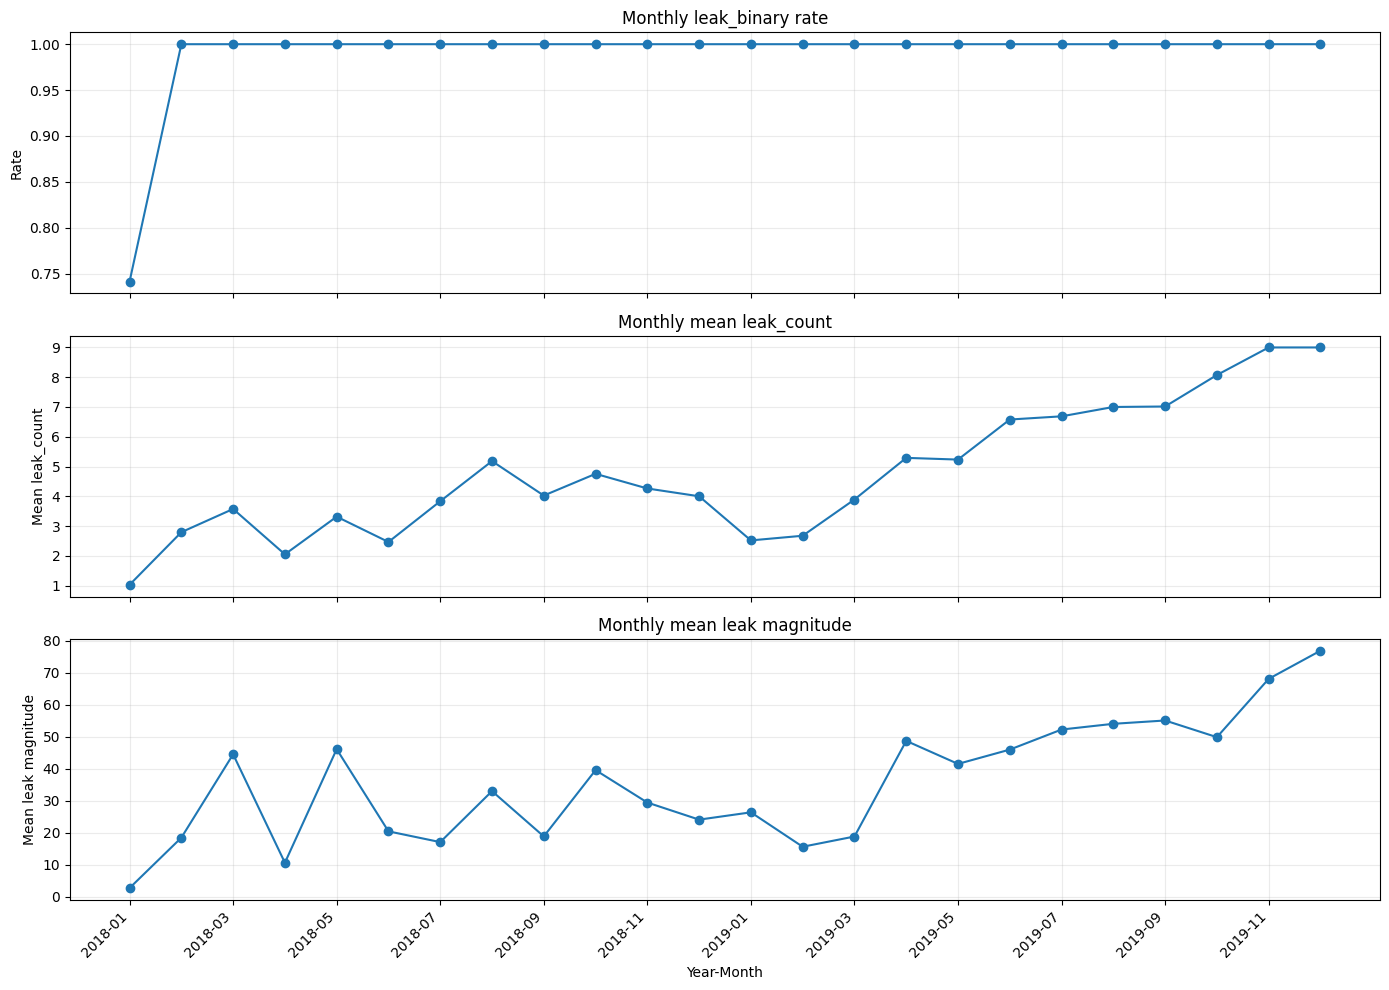

In [12]:
monthly = (
    df.groupby('year_month')
    .agg(
        leak_binary_rate=('leak_binary', 'mean'),
        leak_count_mean=('leak_count', 'mean'),
        leak_mag_mean=('leak_mag_total', 'mean'),
        rows=('Timestamp', 'size')
    )
    .reset_index()
)

display(monthly.head(12))

tick_idx = np.arange(0, len(monthly), 2)
labels = monthly['year_month']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(monthly['year_month'], monthly['leak_binary_rate'], marker='o')
axes[0].set_title('Monthly leak_binary rate')
axes[0].set_ylabel('Rate')

axes[1].plot(monthly['year_month'], monthly['leak_count_mean'], marker='o')
axes[1].set_title('Monthly mean leak_count')
axes[1].set_ylabel('Mean leak_count')

axes[2].plot(monthly['year_month'], monthly['leak_mag_mean'], marker='o')
axes[2].set_title('Monthly mean leak magnitude')
axes[2].set_ylabel('Mean leak magnitude')
axes[2].set_xlabel('Year-Month')
axes[2].set_xticks(tick_idx)
axes[2].set_xticklabels(labels.iloc[tick_idx], rotation=45, ha='right')

plt.tight_layout()
plt.show()

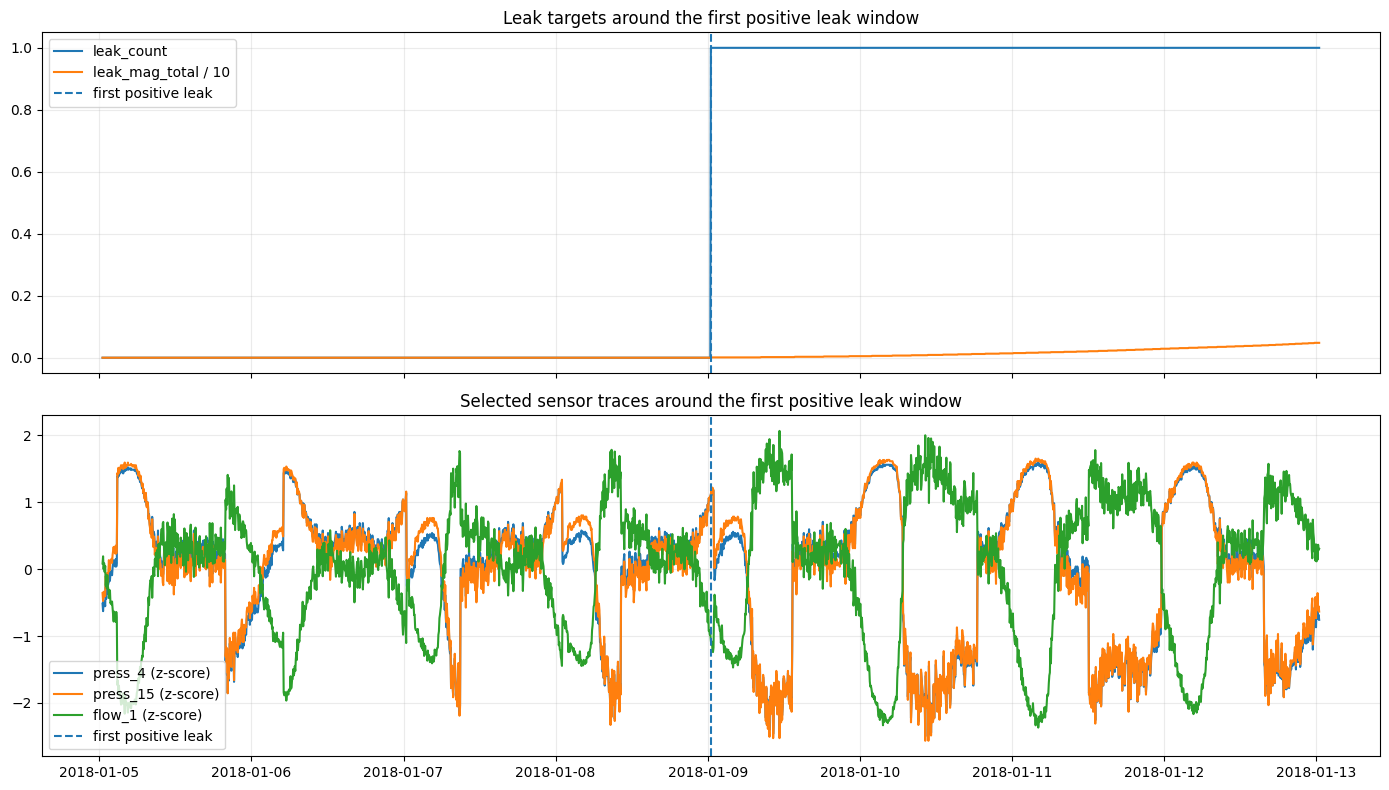

In [13]:
first_leak_ts = df.loc[df['leak_binary'].eq(1), 'Timestamp'].min()
window = df[(df['Timestamp'] >= first_leak_ts - pd.Timedelta(days=4)) & (df['Timestamp'] <= first_leak_ts + pd.Timedelta(days=4))].copy()

window_targets = window[['Timestamp', 'leak_count', 'leak_mag_total']].copy()
selected_sensor_window_cols = ['press_4', 'press_15', 'flow_1']
window_scaled = (window[selected_sensor_window_cols] - window[selected_sensor_window_cols].mean()) / window[selected_sensor_window_cols].std()
window_scaled['Timestamp'] = window['Timestamp'].values

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(window_targets['Timestamp'], window_targets['leak_count'], label='leak_count')
axes[0].plot(window_targets['Timestamp'], window_targets['leak_mag_total'] / 10.0, label='leak_mag_total / 10')
axes[0].axvline(first_leak_ts, linestyle='--', label='first positive leak')
axes[0].set_title('Leak targets around the first positive leak window')
axes[0].legend()

for col in selected_sensor_window_cols:
    axes[1].plot(window_scaled['Timestamp'], window_scaled[col], label=f'{col} (z-score)')
axes[1].axvline(first_leak_ts, linestyle='--', label='first positive leak')
axes[1].set_title('Selected sensor traces around the first positive leak window')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5) Sensor statistics and feature relationships

In [14]:
def summarize_group(cols, group_name):
    stats = df[cols].agg(['mean', 'std', 'min', 'max']).T
    return pd.Series({
        'group': group_name,
        'n_columns': len(cols),
        'mean_of_means': stats['mean'].mean(),
        'mean_std': stats['std'].mean(),
        'overall_min': stats['min'].min(),
        'overall_max': stats['max'].max(),
    })

group_summary = pd.DataFrame([
    summarize_group(press_cols, 'pressure_sensor'),
    summarize_group(flow_cols, 'flow_sensor'),
    summarize_group(node_cols, 'node_sensor'),
    summarize_group(other_sensor_cols, 'other_sensor'),
])

display(group_summary)

,group,n_columns,mean_of_means,mean_std,overall_min,overall_max
0,pressure_sensor,33,46.005,0.621,25.670,56.970
1,flow_sensor,3,85.582,29.969,0.000,205.440
2,node_sensor,82,214.694,192.968,0.000,"37,795.880"
3,other_sensor,1,3.114,0.459,1.950,3.900


In [15]:
sensor_stats = df[sensor_cols].agg(['mean', 'std', 'min', 'max']).T.sort_values('std', ascending=False)

top_var_pressure = sensor_stats.loc[press_cols].sort_values('std', ascending=False).head(10)
top_var_nodes = sensor_stats.loc[node_cols].sort_values('std', ascending=False).head(10)

top_corr_count = (
    df[sensor_cols]
    .corrwith(df['leak_count'])
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(15)
    .rename('corr_with_leak_count')
    .to_frame()
)

top_corr_mag = (
    df[sensor_cols]
    .corrwith(df['leak_mag_total'])
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(15)
    .rename('corr_with_leak_mag_total')
    .to_frame()
)

print('Top variance pressure sensors')
display(top_var_pressure)
print('Top variance node sensors')
display(top_var_nodes)
print('Top sensor correlations with leak_count')
display(top_corr_count)
print('Top sensor correlations with leak_mag_total')
display(top_corr_mag)

Top variance pressure sensors


,mean,std,min,max
press_15,30.225,1.002,27.240,32.120
press_4,36.408,0.964,33.580,38.290
press_17,36.030,0.928,33.220,37.810
press_10,51.746,0.862,49.070,53.380
press_14,45.983,0.843,43.380,47.600
press_18,42.777,0.821,40.220,44.360
press_25,55.387,0.815,52.740,56.960
press_27,46.849,0.797,44.220,48.300
press_7,51.841,0.781,49.380,53.350
press_8,54.597,0.767,52.140,56.080


Top variance node sensors


,mean,std,min,max
n25,"1,835.341","3,749.274",0.000,"37,795.880"
n4,"1,443.868","1,840.873",96.550,"12,882.550"
n1,629.021,"1,103.613",3.910,"7,759.880"
n358,523.540,358.235,0.000,"1,811.740"
n11,510.448,346.180,0.000,"1,681.820"
n9,434.199,302.543,0.000,"1,461.480"
n17,408.995,281.846,0.000,"1,392.140"
n7,399.488,281.706,0.000,"1,379.410"
n351,409.150,277.347,0.000,"1,393.520"
n355,399.933,275.111,0.000,"1,351.530"


Top sensor correlations with leak_count


,corr_with_leak_count
press_27,-0.658
press_11,-0.652
press_33,-0.650
press_32,-0.649
press_28,-0.641
press_30,-0.636
press_15,-0.631
press_26,-0.622
press_10,-0.620
press_29,-0.619


Top sensor correlations with leak_mag_total


,corr_with_leak_mag_total
press_27,-0.592
press_10,-0.592
press_11,-0.576
press_15,-0.576
press_28,-0.572
press_33,-0.571
press_14,-0.571
press_25,-0.571
press_26,-0.570
press_32,-0.569


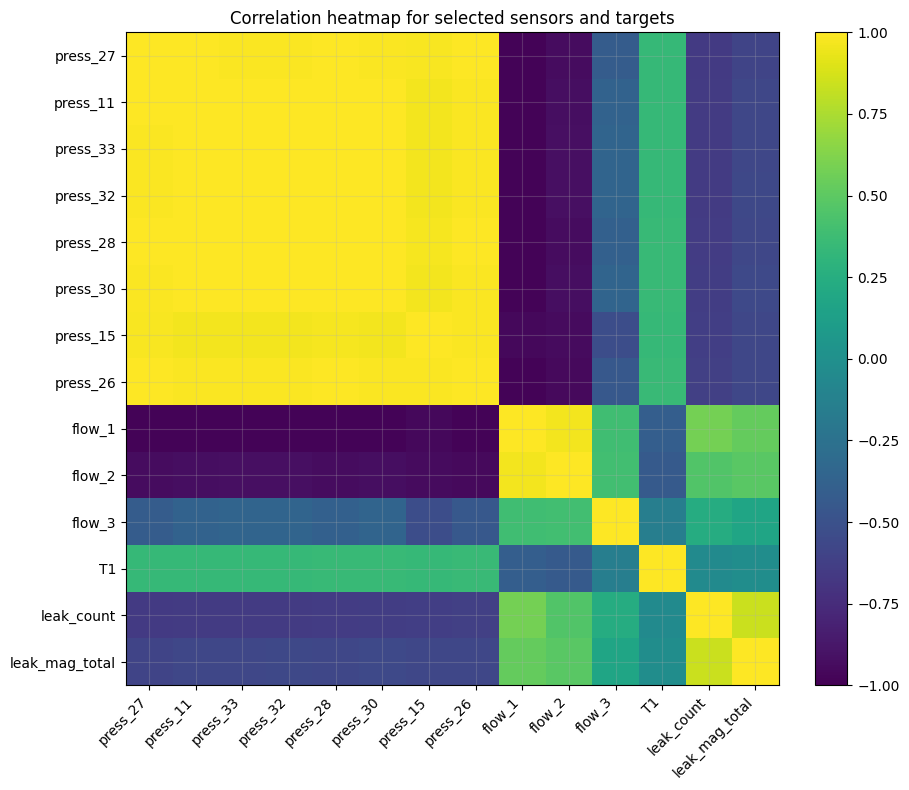

In [16]:
selected_corr_features = list(dict.fromkeys(top_corr_count.index[:8].tolist() + ['flow_1', 'flow_2', 'flow_3', 'T1']))
corr_frame = df[selected_corr_features + ['leak_count', 'leak_mag_total']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_frame, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_frame.columns)))
ax.set_xticklabels(corr_frame.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr_frame.index)))
ax.set_yticklabels(corr_frame.index)
ax.set_title('Correlation heatmap for selected sensors and targets')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

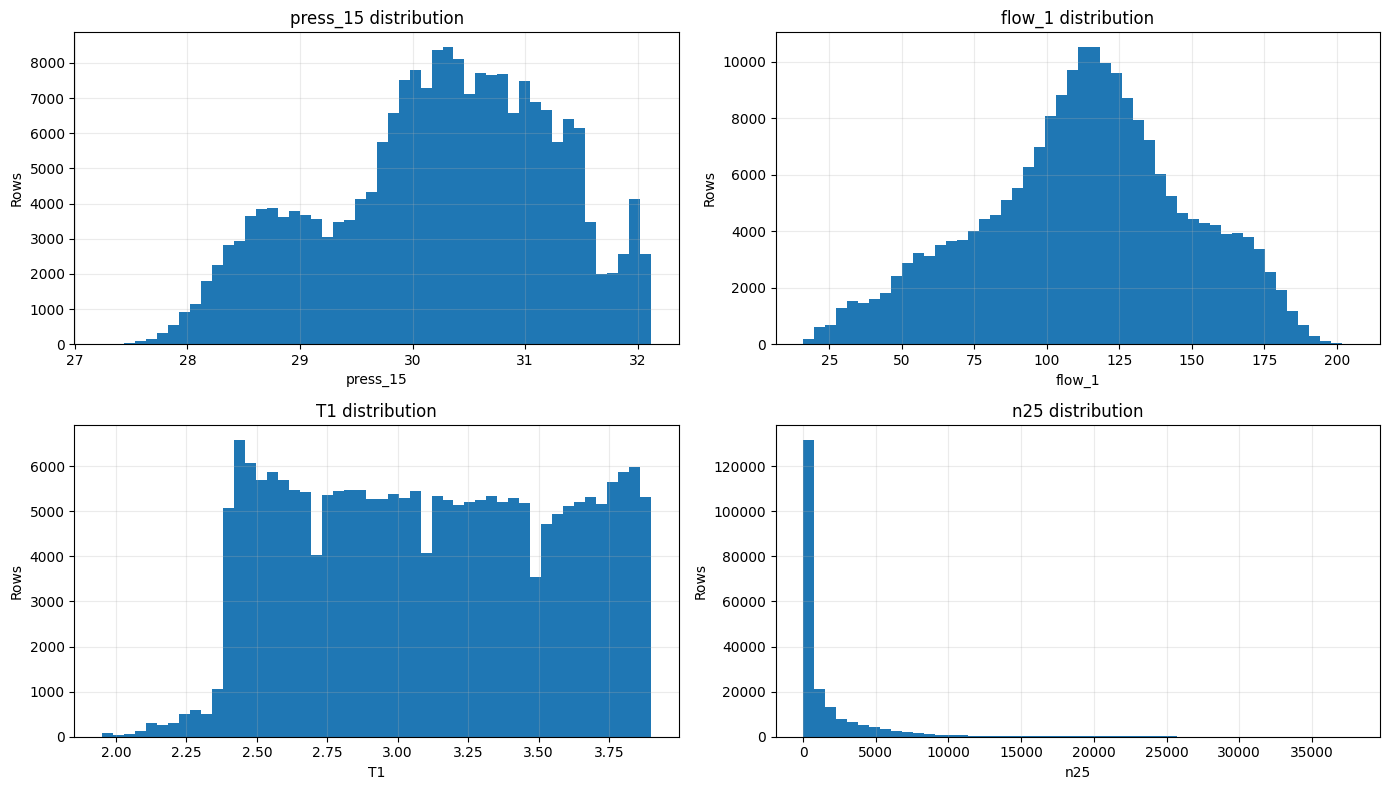

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_cols = ['press_15', 'flow_1', 'T1', 'n25']
for ax, col in zip(axes.ravel(), plot_cols):
    ax.hist(df[col], bins=50)
    ax.set_title(f'{col} distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Rows')
plt.tight_layout()
plt.show()